In [2]:
import pickle
importance = pickle.load(open('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/importance/shap.pkl', 'rb'))

In [30]:
actuals = []
preds = []
diffs = []
propDiffs = []
for x in importance:
    actual,pred = x.text.split(' Pred:')
    diff = float(pred) - float(actual)
    actuals.append(float(actual))
    preds.append(float(pred))
    diffs.append(diff)
    propDiff = diff / float(actual) if float(actual) != 0 else 0
    propDiffs.append(propDiff)

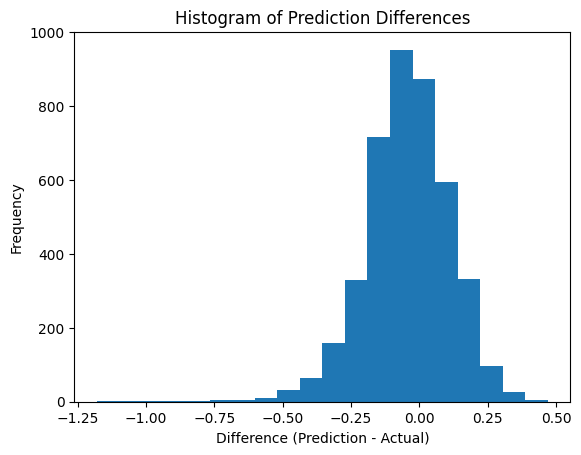

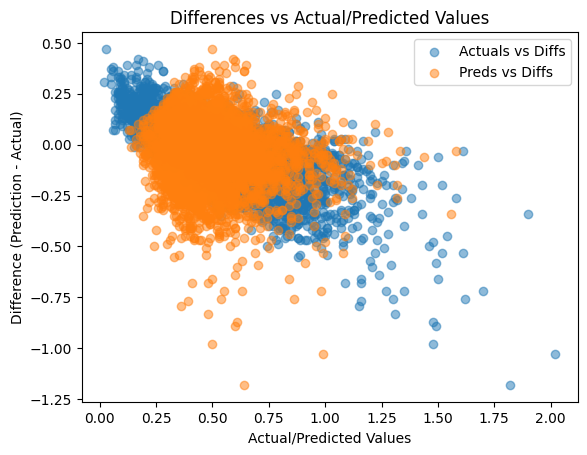

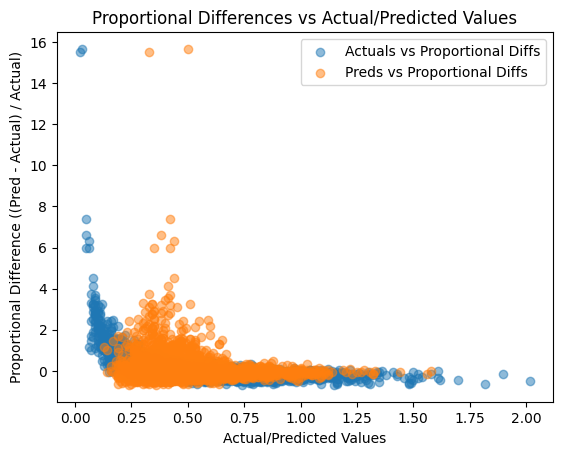

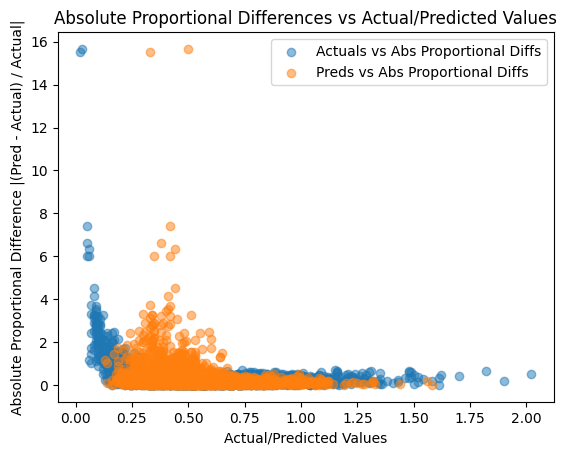

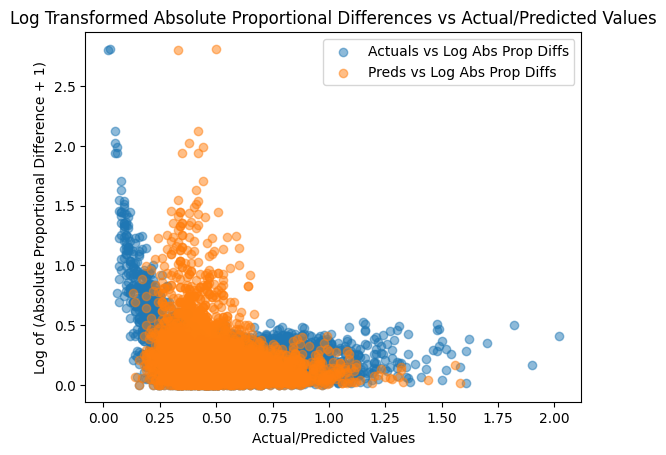

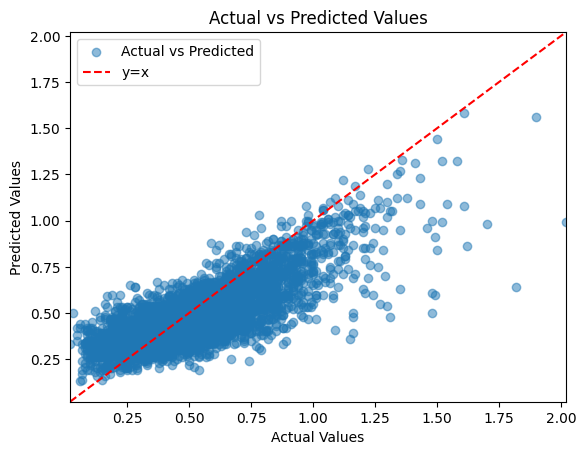

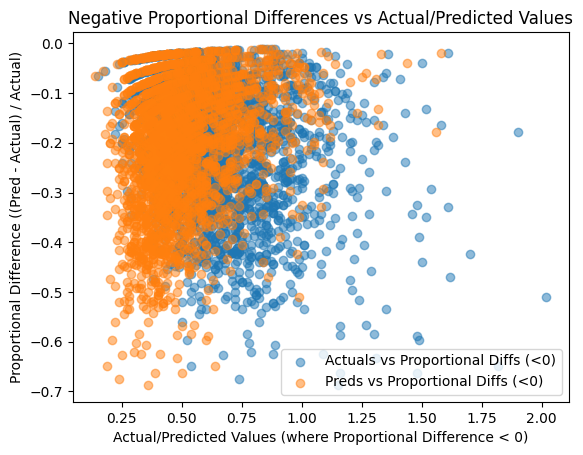

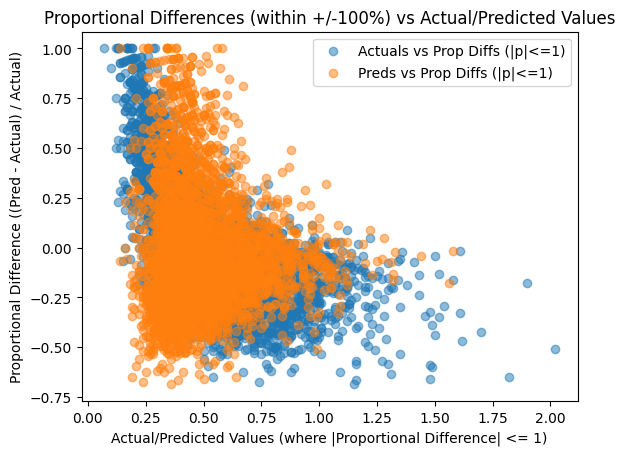

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(diffs, bins=20)
plt.xlabel("Difference (Prediction - Actual)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Differences")
plt.show()

# plot diffs against actuals and preds
plt.scatter(actuals, diffs, label='Actuals vs Diffs', alpha=0.5)
plt.scatter(preds, diffs, label='Preds vs Diffs', alpha=0.5)
plt.xlabel("Actual/Predicted Values")
plt.ylabel("Difference (Prediction - Actual)")
plt.title("Differences vs Actual/Predicted Values")
plt.legend()
plt.show()

# plot propDiffs against actuals and preds
plt.scatter(actuals, propDiffs, label='Actuals vs Proportional Diffs', alpha=0.5)
plt.scatter(preds, propDiffs, label='Preds vs Proportional Diffs', alpha=0.5)
plt.xlabel("Actual/Predicted Values")
plt.ylabel("Proportional Difference ((Pred - Actual) / Actual)")
plt.title("Proportional Differences vs Actual/Predicted Values")
plt.legend()
plt.show()

# plot absolute propDiffs against actuals and preds
plt.scatter(actuals, np.abs(propDiffs), label='Actuals vs Abs Proportional Diffs', alpha=0.5)
plt.scatter(preds, np.abs(propDiffs), label='Preds vs Abs Proportional Diffs', alpha=0.5)
plt.xlabel("Actual/Predicted Values")
plt.ylabel("Absolute Proportional Difference |(Pred - Actual) / Actual|")
plt.title("Absolute Proportional Differences vs Actual/Predicted Values")
plt.legend()
plt.show()

# plot log of absolute propDiffs against actuals and preds
plt.scatter(actuals, np.log(np.array(np.abs(propDiffs))+1), label='Actuals vs Log Abs Prop Diffs', alpha=0.5)
plt.scatter(preds, np.log(np.array(np.abs(propDiffs))+1), label='Preds vs Log Abs Prop Diffs', alpha=0.5)
plt.xlabel("Actual/Predicted Values")
plt.ylabel("Log of (Absolute Proportional Difference + 1)")
plt.title("Log Transformed Absolute Proportional Differences vs Actual/Predicted Values")
plt.legend()
plt.show()

# Determine the common range for both axes
min_val = min(min(actuals), min(preds))
max_val = max(max(actuals), max(preds))

plt.scatter(actuals, preds, label='Actual vs Predicted', alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

# Set the same limits for both axes
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Add a red y=x line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')

plt.legend()
plt.show()

# plot propDiffs < 0 against actuals and preds
plt.scatter([a for a,p in zip(actuals,propDiffs) if p < 0], [p for a,p in zip(actuals,propDiffs) if p < 0], label='Actuals vs Proportional Diffs (<0)', alpha=0.5)
plt.scatter([a for a,p in zip(preds,propDiffs) if p < 0], [p for a,p in zip(preds,propDiffs) if p < 0], label='Preds vs Proportional Diffs (<0)', alpha=0.5)
plt.xlabel("Actual/Predicted Values (where Proportional Difference < 0)")
plt.ylabel("Proportional Difference ((Pred - Actual) / Actual)")
plt.title("Negative Proportional Differences vs Actual/Predicted Values")
plt.legend()
plt.show()

# plot propDiffs where abs(propDiffs) <= 1 against actuals and preds
plt.scatter([a for a,p in zip(actuals,propDiffs) if abs(p) <= 1], [p for a,p in zip(actuals,propDiffs) if abs(p) <= 1], label='Actuals vs Prop Diffs (|p|<=1)', alpha=0.5)
plt.scatter([a for a,p in zip(preds,propDiffs) if abs(p) <= 1], [p for a,p in zip(preds,propDiffs) if abs(p) <= 1], label='Preds vs Prop Diffs (|p|<=1)', alpha=0.5)
plt.xlabel("Actual/Predicted Values (where |Proportional Difference| <= 1)")
plt.ylabel("Proportional Difference ((Pred - Actual) / Actual)")
plt.title("Proportional Differences (within +/-100%) vs Actual/Predicted Values")
plt.legend()
plt.show()

In [24]:
print(len(propDiffs))
print(sum(p <= 1 for p in propDiffs))

4213
4034


Are these really low values that same the genes that dispersion would have removed?

In [25]:
x

Explanation(text='0.36 Pred:0.3', tokens=['', 'GCAGGC', 'TTATAGC', 'GC', 'ATCTGGC', 'ACATAAC', 'ACGG', 'TTCACG', 'AAAGAA', 'TTTTTTC', 'AAACC', 'TAAAGAA', 'TTGTTAA', 'TTTG', 'ATCG', 'AACTATC', 'ATATT', 'TGATGGGG', 'ATGCTAC', 'TGTATG', 'TAATTG', 'AAAGCG', 'ATCATAG', 'TTTTCTTCC', 'TAAATGG', 'ACGC', 'TTAATAA', 'ATAGG', 'ATCTAG', 'TCTTTC', 'TATTTGC', 'GGCG', 'TTATTGG', 'TGTTGG', 'TTGC', 'TGTTTG', 'TGG', 'TTCG', 'TCG', 'TGCATG', 'AGCAGC', 'AGAAAGTGG', 'AAAA', 'TTATAA', 'TAAATCTC', 'ATCCAGAA', 'TTCTGTTTTG', 'ATTCCG', 'ATACATC', 'GCG', 'AATTTAA', 'ATTAACG', 'ACTAA', 'ACGTGC', 'AACGG', 'TGCTGTG', 'AGGC', 'AAATTAATAA', 'ATTCTGC', 'GGC', 'ATACTAC', 'TGTTC', 'TTCGGG', 'TGTGTGTG', 'TATTC', 'ATACACG', 'ACATG', 'TGTGC', 'ACATAC', 'ATATG', 'TCTGC', 'ATGTAC', 'ATTCG', 'AAATTG', 'AAATT', 'ATGCAAAA', 'TGTGC', 'ATCATAC', 'TGCG', 'AACGC', 'TAG', 'TTAAGG', 'AGCAGTGC', 'TTC', 'AATTGC', 'TAC', 'TTCG', 'ATGGAAATG', 'TAAC', 'TGTTAC', 'GTAC', 'TGTGTTC', 'GCG', 'ATTTCC', 'CCCG', 'TAC', 'TTATCC', 'TGTGCC', 'TAA', 

Number of points flagged as outliers: 180
Standard deviation of deviations from LOESS: 0.1036
Threshold for outliers (2*std_dev): 0.2071


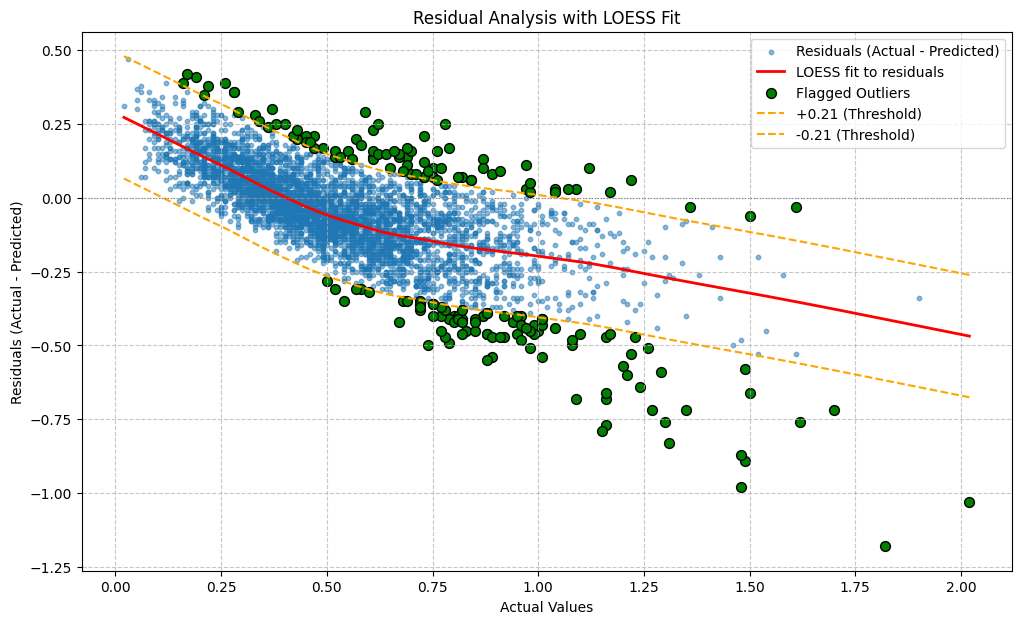

In [32]:
import numpy as np

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Convert lists to numpy arrays
actuals_arr = np.array(actuals)
preds_arr = np.array(preds)

# Calculate residuals
residuals = preds_arr - actuals_arr

# Fit LOESS model: residuals ~ actuals
# The frac parameter controls the smoothing. Adjust as needed.
lowess_fit = sm.nonparametric.lowess(residuals, actuals_arr, frac=0.3)

# Get the smoothed y-values (predicted residuals from LOESS)
loess_x = lowess_fit[:, 0]
loess_y_pred_residuals = lowess_fit[:, 1]

# Sort by actuals_arr for correct plotting of LOESS curve
sort_idx = np.argsort(actuals_arr)
actuals_sorted = actuals_arr[sort_idx]
residuals_sorted_by_actuals = residuals[sort_idx]

# Interpolate LOESS predictions to match the original residuals' order for deviation calculation
# This is important because lowess returns sorted x values
loess_pred_residuals_for_deviation = np.interp(actuals_arr, loess_x, loess_y_pred_residuals)

# Calculate the deviation of each residual from the LOESS curve
deviations_from_loess = residuals - loess_pred_residuals_for_deviation

# Calculate the standard deviation of these deviations
std_dev_of_deviations = np.std(deviations_from_loess)

# Define a threshold for flagging significant deviations (e.g., 2 standard deviations)
threshold = 2 * std_dev_of_deviations

# Flag samples whose residuals deviate significantly
outlier_indices = np.where(np.abs(deviations_from_loess) > threshold)[0]
outlier_actuals = actuals_arr[outlier_indices]
outlier_residuals = residuals[outlier_indices]

print(f"Number of points flagged as outliers: {len(outlier_indices)}")
print(f"Standard deviation of deviations from LOESS: {std_dev_of_deviations:.4f}")
print(f"Threshold for outliers (2*std_dev): {threshold:.4f}")

# Plotting
plt.figure(figsize=(12, 7))
plt.scatter(actuals_arr, residuals, label='Residuals (Actual - Predicted)', alpha=0.5, s=10)
plt.plot(actuals_sorted, loess_y_pred_residuals[np.argsort(loess_x)], color='red', linewidth=2, label='LOESS fit to residuals')
plt.scatter(outlier_actuals, outlier_residuals, color='green', s=50, label='Flagged Outliers', edgecolor='black')

# Plot lines for threshold
plt.plot(actuals_sorted, loess_y_pred_residuals[np.argsort(loess_x)] + threshold, color='orange', linestyle='--', label=f'+{threshold:.2f} (Threshold)')
plt.plot(actuals_sorted, loess_y_pred_residuals[np.argsort(loess_x)] - threshold, color='orange', linestyle='--', label=f'-{threshold:.2f} (Threshold)')


plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis with LOESS Fit")
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# You can access the outlier data points from the 'importance' list if needed
# for i in outlier_indices:
# print(f"Outlier: Actual={actuals_arr[i]}, Predicted={preds_arr[i]}, Residual={residuals[i]}, Text={importance[i].text}")

In [ ]:
filtImportances = [importance[i] for i in range(len(importance)) if i not in outlier_indices]
print(f"Original importance list length: {len(importance)}")
print(f"Filtered importance list length: {len(filtImportances)}")
print(f"Number of outliers removed: {len(outlier_indices)}")